# Initial Data Analysis — NASA C-MAPSS Dataset (FD001)

**Project:** Bayesian Digital Twins for Predictive Maintenance
**Dataset:** NASA Commercial Modular Aero-Propulsion System Simulation (C-MAPSS)
**Sub-dataset:** FD001 — 1 operating condition, HPC degradation
**Goal:** First-pass data quality checks, schema understanding, and structural characterization of FD001, in the same format as `Improved_IDA.ipynb` (which analyses all four sub-datasets together). FD001 and FD003 are the two sub-datasets used for the modelling work in this thesis.

---

## Contents

1. Setup & Imports
2. Data Loading
3. Dataset Dimensions & Schema
4. Data Types & Missing Values
5. Unit / Engine ID Structure
6. Cycle Length Distributions
7. Operating Conditions
8. Sensor Variable Identification
9. Descriptive Statistics
10. RUL Label Structure
11. Summary & Key Findings

---
## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# ── Dataset & Paths ──────────────────────────────────────────────────────────
DATASET   = 'FD001'
DATA_DIR  = Path('../../data/cmapss')
FIG_DIR   = Path('output/figures/IDA') / DATASET
TABLE_DIR = Path('output/tables/IDA') / DATASET
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = sns.color_palette('tab10')

print(f'Setup complete. Dataset: {DATASET}')

Setup complete. Dataset: FD001


---
## 2. Data Loading

C-MAPSS files are whitespace-delimited with no header row.
Each row represents one engine cycle. The 26 columns are:

| Position | Name | Description |
|---|---|---|
| 0 | `unit_id` | Engine (unit) number |
| 1 | `cycle` | Operational cycle counter |
| 2–4 | `setting_1/2/3` | Operational setting variables |
| 5–25 | `s1`–`s21` | Sensor measurements (T2 through W32) |

In [2]:
# ── Column schema ──────────────────────────────────────────────────────────────
INDEX_COLS   = ['unit_id', 'cycle']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']

# Sensor names in order (from readme.txt / Damage Propagation Modeling.pdf)
SENSOR_NAMES = [
    'T2',    # Total temperature at fan inlet (°R)
    'T24',   # Total temperature at LPC outlet (°R)
    'T30',   # Total temperature at HPC outlet (°R)
    'T50',   # Total temperature at LPT outlet (°R)
    'P2',    # Pressure at fan inlet (psia)
    'P15',   # Total pressure in bypass-duct (psia)
    'P30',   # Total pressure at HPC outlet (psia)
    'Nf',    # Physical fan speed (rpm)
    'Nc',    # Physical core speed (rpm)
    'epr',   # Engine pressure ratio (P50/P2)
    'Ps30',  # Static pressure at HPC outlet (psia)
    'phi',   # Ratio of fuel flow to Ps30
    'NRf',   # Corrected fan speed (rpm)
    'NRc',   # Corrected core speed (rpm)
    'BPR',   # Bypass ratio
    'farB',  # Burner fuel-air ratio
    'htBleed', # Bleed enthalpy
    'Nf_dmd',  # Demanded fan speed (rpm)
    'PCNfR_dmd', # Demanded corrected fan speed (rpm)
    'W31',   # HPT coolant bleed (lbm/s)
    'W32',   # LPT coolant bleed (lbm/s)
]

ALL_COLS = INDEX_COLS + SETTING_COLS + SENSOR_NAMES

print(f'Total columns: {len(ALL_COLS)}')
print(f'Sensor columns: {len(SENSOR_NAMES)}')

Total columns: 26
Sensor columns: 21


In [3]:
def load_dataset(name: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    """Load train, test, and RUL files for one C-MAPSS sub-dataset."""
    train = pd.read_csv(
        DATA_DIR / f'train_{name}.txt',
        sep=r'\s+', header=None, names=ALL_COLS
    )
    test = pd.read_csv(
        DATA_DIR / f'test_{name}.txt',
        sep=r'\s+', header=None, names=ALL_COLS
    )
    rul = pd.read_csv(
        DATA_DIR / f'RUL_{name}.txt',
        sep=r'\s+', header=None, names=['true_rul']
    )['true_rul']
    return train, test, rul


def add_rul(df: pd.DataFrame) -> pd.DataFrame:
    """Compute and append RUL column for a training set."""
    df = df.copy()
    max_cycle = df.groupby('unit_id')['cycle'].transform('max')
    df['RUL'] = max_cycle - df['cycle']
    return df


# Load the target sub-dataset
train_raw, test, rul = load_dataset(DATASET)
train = add_rul(train_raw)
print(f'{DATASET}: train={train.shape}, test={test.shape}, rul_labels={len(rul)}')

FD001: train=(20631, 27), test=(13096, 26), rul_labels=100


---
## 3. Dataset Dimensions & Schema

**FD001** has **1 operating condition** and fault mode **HPC degradation**.
For comparison, the other sub-dataset used in this thesis, **FD003**, also has 1 operating condition but a different fault-mode combination (see `IDA_FD003.ipynb`).

In [4]:
dim_row = {
    'Dataset':         DATASET,
    'Operating conditions': 1,
    'Fault mode(s)':   'HPC degradation',
    'Train rows':      train.shape[0],
    'Test rows':       test.shape[0],
    'Columns':         len(ALL_COLS),
    'Train engines':   train['unit_id'].nunique(),
    'Test engines':    test['unit_id'].nunique(),
    'RUL labels':      len(rul),
}

dim_df = pd.DataFrame([dim_row]).set_index('Dataset')
display(dim_df)
dim_df.to_csv(TABLE_DIR / 'dataset_dimensions.csv')
print(f'Saved → output/tables/IDA/{DATASET}/dataset_dimensions.csv')

,Operating conditions,Fault mode(s),Train rows,Test rows,Columns,Train engines,Test engines,RUL labels
Dataset,,,,,,,,
FD001,1,HPC degradation,20631,13096,26,100,100,100


Saved → output/tables/IDA/FD001/dataset_dimensions.csv


In [5]:
# Inspect column schema
print('Column names:')
print(train.columns.tolist())
print()
train.head(3)

Column names:
['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32', 'RUL']



,unit_id,cycle,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189


---
## 4. Data Types & Missing Values

In [6]:
print(f'=== Data Types ({DATASET} train) ===')
print(train.dtypes.to_string())

=== Data Types (FD001 train) ===
unit_id        int64
cycle          int64
setting_1    float64
setting_2    float64
setting_3    float64
T2           float64
T24          float64
T30          float64
T50          float64
P2           float64
P15          float64
P30          float64
Nf           float64
Nc           float64
epr          float64
Ps30         float64
phi          float64
NRf          float64
NRc          float64
BPR          float64
farB         float64
htBleed        int64
Nf_dmd         int64
PCNfR_dmd    float64
W31          float64
W32          float64
RUL            int64


In [7]:
# Missing values across train/test
mv_rows = []
for split, df in [('train', train), ('test', test)]:
    n_missing = df.isnull().sum().sum()
    mv_rows.append({'Dataset': DATASET, 'Split': split,
                    'Total cells': df.size,
                    'Missing cells': n_missing,
                    'Missing %': f'{100*n_missing/df.size:.4f}%'})

mv_df = pd.DataFrame(mv_rows)
display(mv_df)
mv_df.to_csv(TABLE_DIR / 'missing_values.csv', index=False)
print('Saved → output/tables/IDA/{}/missing_values.csv'.format(DATASET))

,Dataset,Split,Total cells,Missing cells,Missing %
0,FD001,train,557037,0,0.0000%
1,FD001,test,340496,0,0.0000%


Saved → output/tables/IDA/FD001/missing_values.csv


In [8]:
# Duplicate rows
dup_rows = []
for split, df in [('train', train), ('test', test)]:
    n_dup = df.duplicated().sum()
    dup_rows.append({'Dataset': DATASET, 'Split': split, 'Duplicate rows': n_dup})

display(pd.DataFrame(dup_rows))

,Dataset,Split,Duplicate rows
0,FD001,train,0
1,FD001,test,0


---
## 5. Unit / Engine ID Structure

In [9]:
engine_rows = []
for split, df in [('train', train), ('test', test)]:
    ids = df['unit_id'].unique()
    engine_rows.append({
        'Dataset': DATASET, 'Split': split,
        'Engine IDs (min–max)': f"{ids.min()}–{ids.max()}",
        'Count': len(ids),
        'Contiguous': ids.max() - ids.min() + 1 == len(ids),
    })

eng_df = pd.DataFrame(engine_rows)
display(eng_df)
eng_df.to_csv(TABLE_DIR / 'engine_ids.csv', index=False)
print('Saved → output/tables/IDA/{}/engine_ids.csv'.format(DATASET))

,Dataset,Split,Engine IDs (min–max),Count,Contiguous
0,FD001,train,1–100,100,True
1,FD001,test,1–100,100,True


Saved → output/tables/IDA/FD001/engine_ids.csv


---
## 6. Cycle Length Distributions

Cycle length = number of operational cycles observed per engine. In the training set this equals the engine's lifetime (failure time). In the test set it is a truncated sequence — the engine was still running when observation stopped.

In [10]:
cycle_stats_rows = []
for split, df in [('train', train), ('test', test)]:
    lengths = df.groupby('unit_id')['cycle'].max()
    cycle_stats_rows.append({
        'Dataset': DATASET, 'Split': split,
        'Min cycles': int(lengths.min()),
        'Median cycles': int(lengths.median()),
        'Mean cycles': f'{lengths.mean():.1f}',
        'Max cycles': int(lengths.max()),
        'Std': f'{lengths.std():.1f}',
    })

cs_df = pd.DataFrame(cycle_stats_rows)
display(cs_df)
cs_df.to_csv(TABLE_DIR / 'cycle_length_stats.csv', index=False)
print('Saved → output/tables/IDA/{}/cycle_length_stats.csv'.format(DATASET))

,Dataset,Split,Min cycles,Median cycles,Mean cycles,Max cycles,Std
0,FD001,train,128,199,206.3,362,46.3
1,FD001,test,31,133,131.0,303,53.6


Saved → output/tables/IDA/FD001/cycle_length_stats.csv


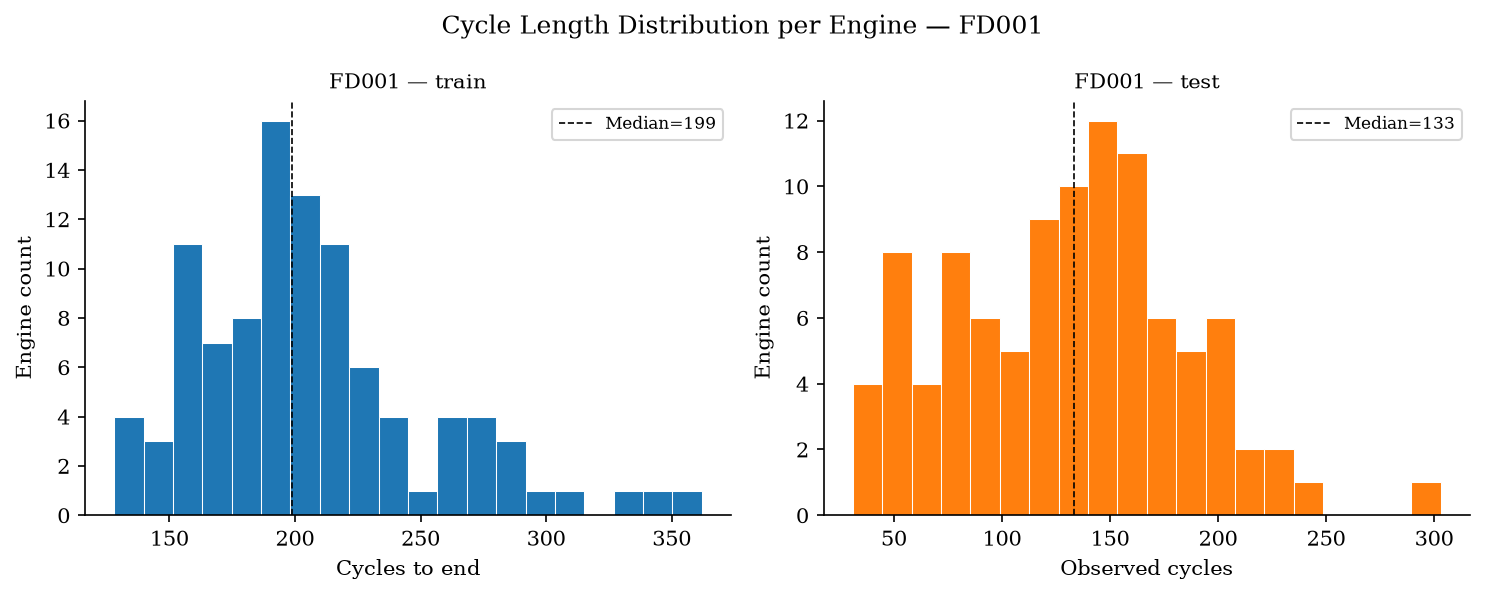

Saved → output/figures/IDA/FD001/cycle_length_distributions.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(f'Cycle Length Distribution per Engine — {DATASET}', fontsize=12)

for ax, (split, df) in zip(axes, [('train', train), ('test', test)]):
    lengths = df.groupby('unit_id')['cycle'].max()
    ax.hist(lengths, bins=20, color=PALETTE[0] if split == 'train' else PALETTE[1],
            edgecolor='white', linewidth=0.5)
    ax.set_title(f'{DATASET} — {split}', fontsize=10)
    ax.set_xlabel('Cycles to end' if split == 'train' else 'Observed cycles')
    ax.set_ylabel('Engine count')
    ax.axvline(lengths.median(), color='k', linestyle='--', linewidth=0.8, label=f'Median={int(lengths.median())}')
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / 'cycle_length_distributions.png', bbox_inches='tight')
plt.show()
print(f'Saved → output/figures/IDA/{DATASET}/cycle_length_distributions.png')

---
## 7. Operating Conditions

Three operational setting variables (`setting_1`, `setting_2`, `setting_3`) encode the flight regime. FD001/FD003 use a single operating condition (unlike FD002/FD004, which use six). This matters for sensor normalization — with one condition, raw sensor values are directly comparable across the whole dataset without per-cluster normalization.

In [12]:
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']

oc_rows = []
for col in SETTING_COLS:
    oc_rows.append({
        'Dataset': DATASET,
        'Setting': col,
        'Unique values (raw)': train[col].nunique(),
        'Unique values (rounded)': train[col].round(2).nunique(),
        'Min': train[col].min(),
        'Max': train[col].max(),
        'Sample values': str(sorted(train[col].unique())[:8]),
    })

oc_df = pd.DataFrame(oc_rows)
display(oc_df)
oc_df.to_csv(TABLE_DIR / 'operating_conditions.csv', index=False)
print('Saved → output/tables/IDA/{}/operating_conditions.csv'.format(DATASET))
print()
print('Rounded to 2 d.p., setting_1/2/3 collapse to a single value each → confirms 1 operating condition.')

,Dataset,Setting,Unique values (raw),Unique values (rounded),Min,Max,Sample values
0,FD001,setting_1,158,3,-0.0087,0.0087,"[np.float64(-0.0087), np.float64(-0.0086), np...."
1,FD001,setting_2,13,1,-0.0006,0.0006,"[np.float64(-0.0006), np.float64(-0.0005), np...."
2,FD001,setting_3,1,1,100.0000,100.0000,[np.float64(100.0)]


Saved → output/tables/IDA/FD001/operating_conditions.csv

Rounded to 2 d.p., setting_1/2/3 collapse to a single value each → confirms 1 operating condition.


---
## 8. Sensor Variable Identification

Not all 21 sensors carry information — some are constant (zero variance), others are highly collinear. We identify, for **this specific sub-dataset**:
- **Constant sensors:** standard deviation ≈ 0 (< 1e-6) across the training set
- **Near-constant sensors:** coefficient of variation < 0.01 (raw physical units)

In [13]:
sensor_info_rows = []
for s in SENSOR_NAMES:
    vals = train[s]
    std = vals.std()
    mean = vals.mean()
    cv = std / abs(mean) if mean != 0 else np.nan
    sensor_info_rows.append({
        'Dataset': DATASET, 'Sensor': s,
        'Mean': round(mean, 4), 'Std': round(std, 6),
        'CV': round(cv, 6) if not np.isnan(cv) else np.nan,
        'Constant': std < 1e-6,
        'Near-constant (CV<0.01)': (not np.isnan(cv)) and (cv < 0.01),
    })

si_df = pd.DataFrame(sensor_info_rows)
si_df.to_csv(TABLE_DIR / 'sensor_variability.csv', index=False)
print('Saved → output/tables/IDA/{}/sensor_variability.csv'.format(DATASET))

const_this_ds = si_df.loc[si_df['Constant'], 'Sensor'].tolist()
print(f'\nConstant sensors in {DATASET} alone (std < 1e-6): {const_this_ds}')
display(si_df.set_index('Sensor'))

Saved → output/tables/IDA/FD001/sensor_variability.csv

Constant sensors in FD001 alone (std < 1e-6): ['T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']


,Dataset,Mean,Std,CV,Constant,Near-constant (CV<0.01)
Sensor,,,,,,
T2,FD001,518.6700,0.000000,0.000000,True,True
T24,FD001,642.6809,0.500053,0.000778,False,True
T30,FD001,1590.5231,6.131150,0.003855,False,True
T50,FD001,1408.9338,9.000605,0.006388,False,True
P2,FD001,14.6200,0.000000,0.000000,True,True
P15,FD001,21.6098,0.001389,0.000064,False,True
P30,FD001,553.3677,0.885092,0.001599,False,True
Nf,FD001,2388.0967,0.070985,0.000030,False,True
Nc,FD001,9065.2429,22.082880,0.002436,False,True


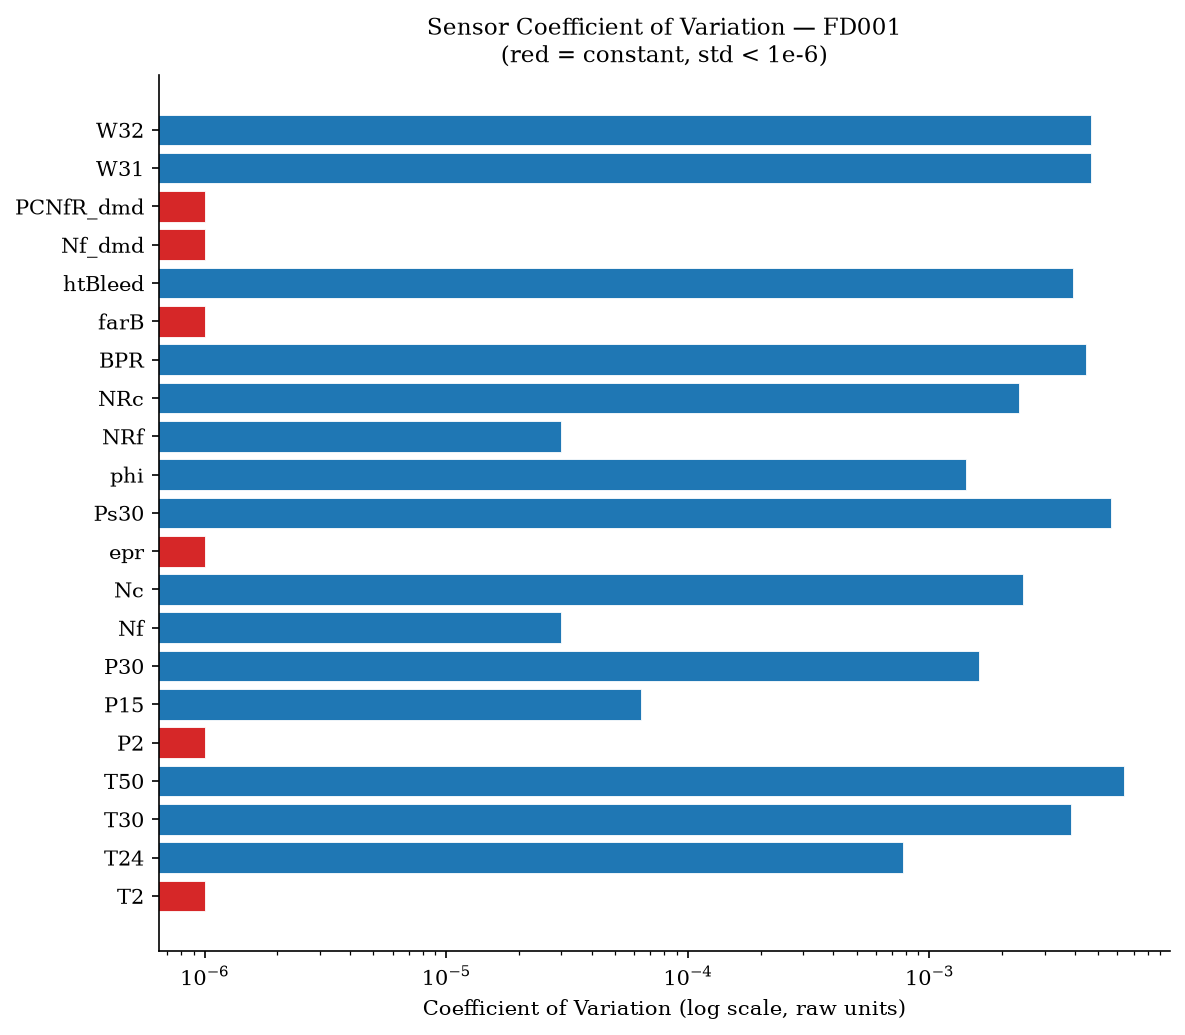

Saved → output/figures/IDA/FD001/sensor_cv_barchart.png


In [14]:
# Sensor CV bar chart (log scale) — single dataset view of the same
# 'darker/shorter = more constant' idea used in the 4-dataset CV heatmap.
plot_df = si_df.set_index('Sensor').loc[SENSOR_NAMES].copy()
plot_df['CV_clipped'] = plot_df['CV'].clip(lower=1e-6)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#d62728' if c else '#1f77b4' for c in plot_df['Constant']]
ax.barh(plot_df.index, plot_df['CV_clipped'], color=colors, edgecolor='white', linewidth=0.4)
ax.set_xscale('log')
ax.set_xlabel('Coefficient of Variation (log scale, raw units)')
ax.set_title(f'Sensor Coefficient of Variation — {DATASET}\n(red = constant, std < 1e-6)', fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / 'sensor_cv_barchart.png', bbox_inches='tight')
plt.show()
print(f'Saved → output/figures/IDA/{DATASET}/sensor_cv_barchart.png')

In [15]:
# Summary: informative vs constant vs near-constant sensors
n_const = si_df['Constant'].sum()
n_near  = si_df['Near-constant (CV<0.01)'].sum() - n_const
n_info  = len(si_df) - n_const - n_near
print(f'{DATASET}: {n_info} informative | {n_near} near-constant (CV<0.01, raw units) | {n_const} constant')
print(f'Constant sensors: {const_this_ds}')
print()
print('Note: with a single operating condition, nearly all remaining sensors show low raw-unit')
print('CV (large baseline, small absolute range), so CV<0.01 is not by itself a reliable informativeness')
print('filter here — it mainly separates truly-constant sensors from everything else. The project-wide')
print('convention (Improved_IDA.ipynb, computed across FD001-FD004) drops 7 sensors as constant:')
print("  ['T2', 'P2', 'P15', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']")
print('This notebook keeps that same 7-sensor exclusion list for consistency with the EDA sensor-selection')
print('pipeline used throughout the project, even though 1-2 of those (e.g. P15, epr) show a small but')
print(f'non-zero std specific to {DATASET} (see table above) — real degradation-relevant signal is assessed')
print('properly via Mann-Kendall / monotonicity / trendability / MI in the EDA notebook, not via raw CV.')

FD001: 0 informative | 15 near-constant (CV<0.01, raw units) | 6 constant
Constant sensors: ['T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']

Note: with a single operating condition, nearly all remaining sensors show low raw-unit
CV (large baseline, small absolute range), so CV<0.01 is not by itself a reliable informativeness
filter here — it mainly separates truly-constant sensors from everything else. The project-wide
convention (Improved_IDA.ipynb, computed across FD001-FD004) drops 7 sensors as constant:
  ['T2', 'P2', 'P15', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
This notebook keeps that same 7-sensor exclusion list for consistency with the EDA sensor-selection
pipeline used throughout the project, even though 1-2 of those (e.g. P15, epr) show a small but
non-zero std specific to FD001 (see table above) — real degradation-relevant signal is assessed
properly via Mann-Kendall / monotonicity / trendability / MI in the EDA notebook, not via raw CV.


---
## 9. Descriptive Statistics

In [16]:
CONSTANT_SENSORS = ['T2', 'P2', 'P15', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
INFORMATIVE_SENSORS = [s for s in SENSOR_NAMES if s not in CONSTANT_SENSORS]  # 14 sensors

stats = train[SENSOR_NAMES].describe().T.round(3)
stats.to_csv(TABLE_DIR / f'descriptive_stats_{DATASET}.csv')
print(f'{DATASET} descriptive stats saved.')
display(stats)

FD001 descriptive stats saved.


,count,mean,std,min,25%,50%,75%,max
T2,20631.0,518.670,0.000,518.670,518.670,518.670,518.670,518.670
T24,20631.0,642.681,0.500,641.210,642.325,642.640,643.000,644.530
T30,20631.0,1590.523,6.131,1571.040,1586.260,1590.100,1594.380,1616.910
T50,20631.0,1408.934,9.001,1382.250,1402.360,1408.040,1414.555,1441.490
P2,20631.0,14.620,0.000,14.620,14.620,14.620,14.620,14.620
P15,20631.0,21.610,0.001,21.600,21.610,21.610,21.610,21.610
P30,20631.0,553.368,0.885,549.850,552.810,553.440,554.010,556.060
Nf,20631.0,2388.097,0.071,2387.900,2388.050,2388.090,2388.140,2388.560
Nc,20631.0,9065.243,22.083,9021.730,9053.100,9060.660,9069.420,9244.590
epr,20631.0,1.300,0.000,1.300,1.300,1.300,1.300,1.300


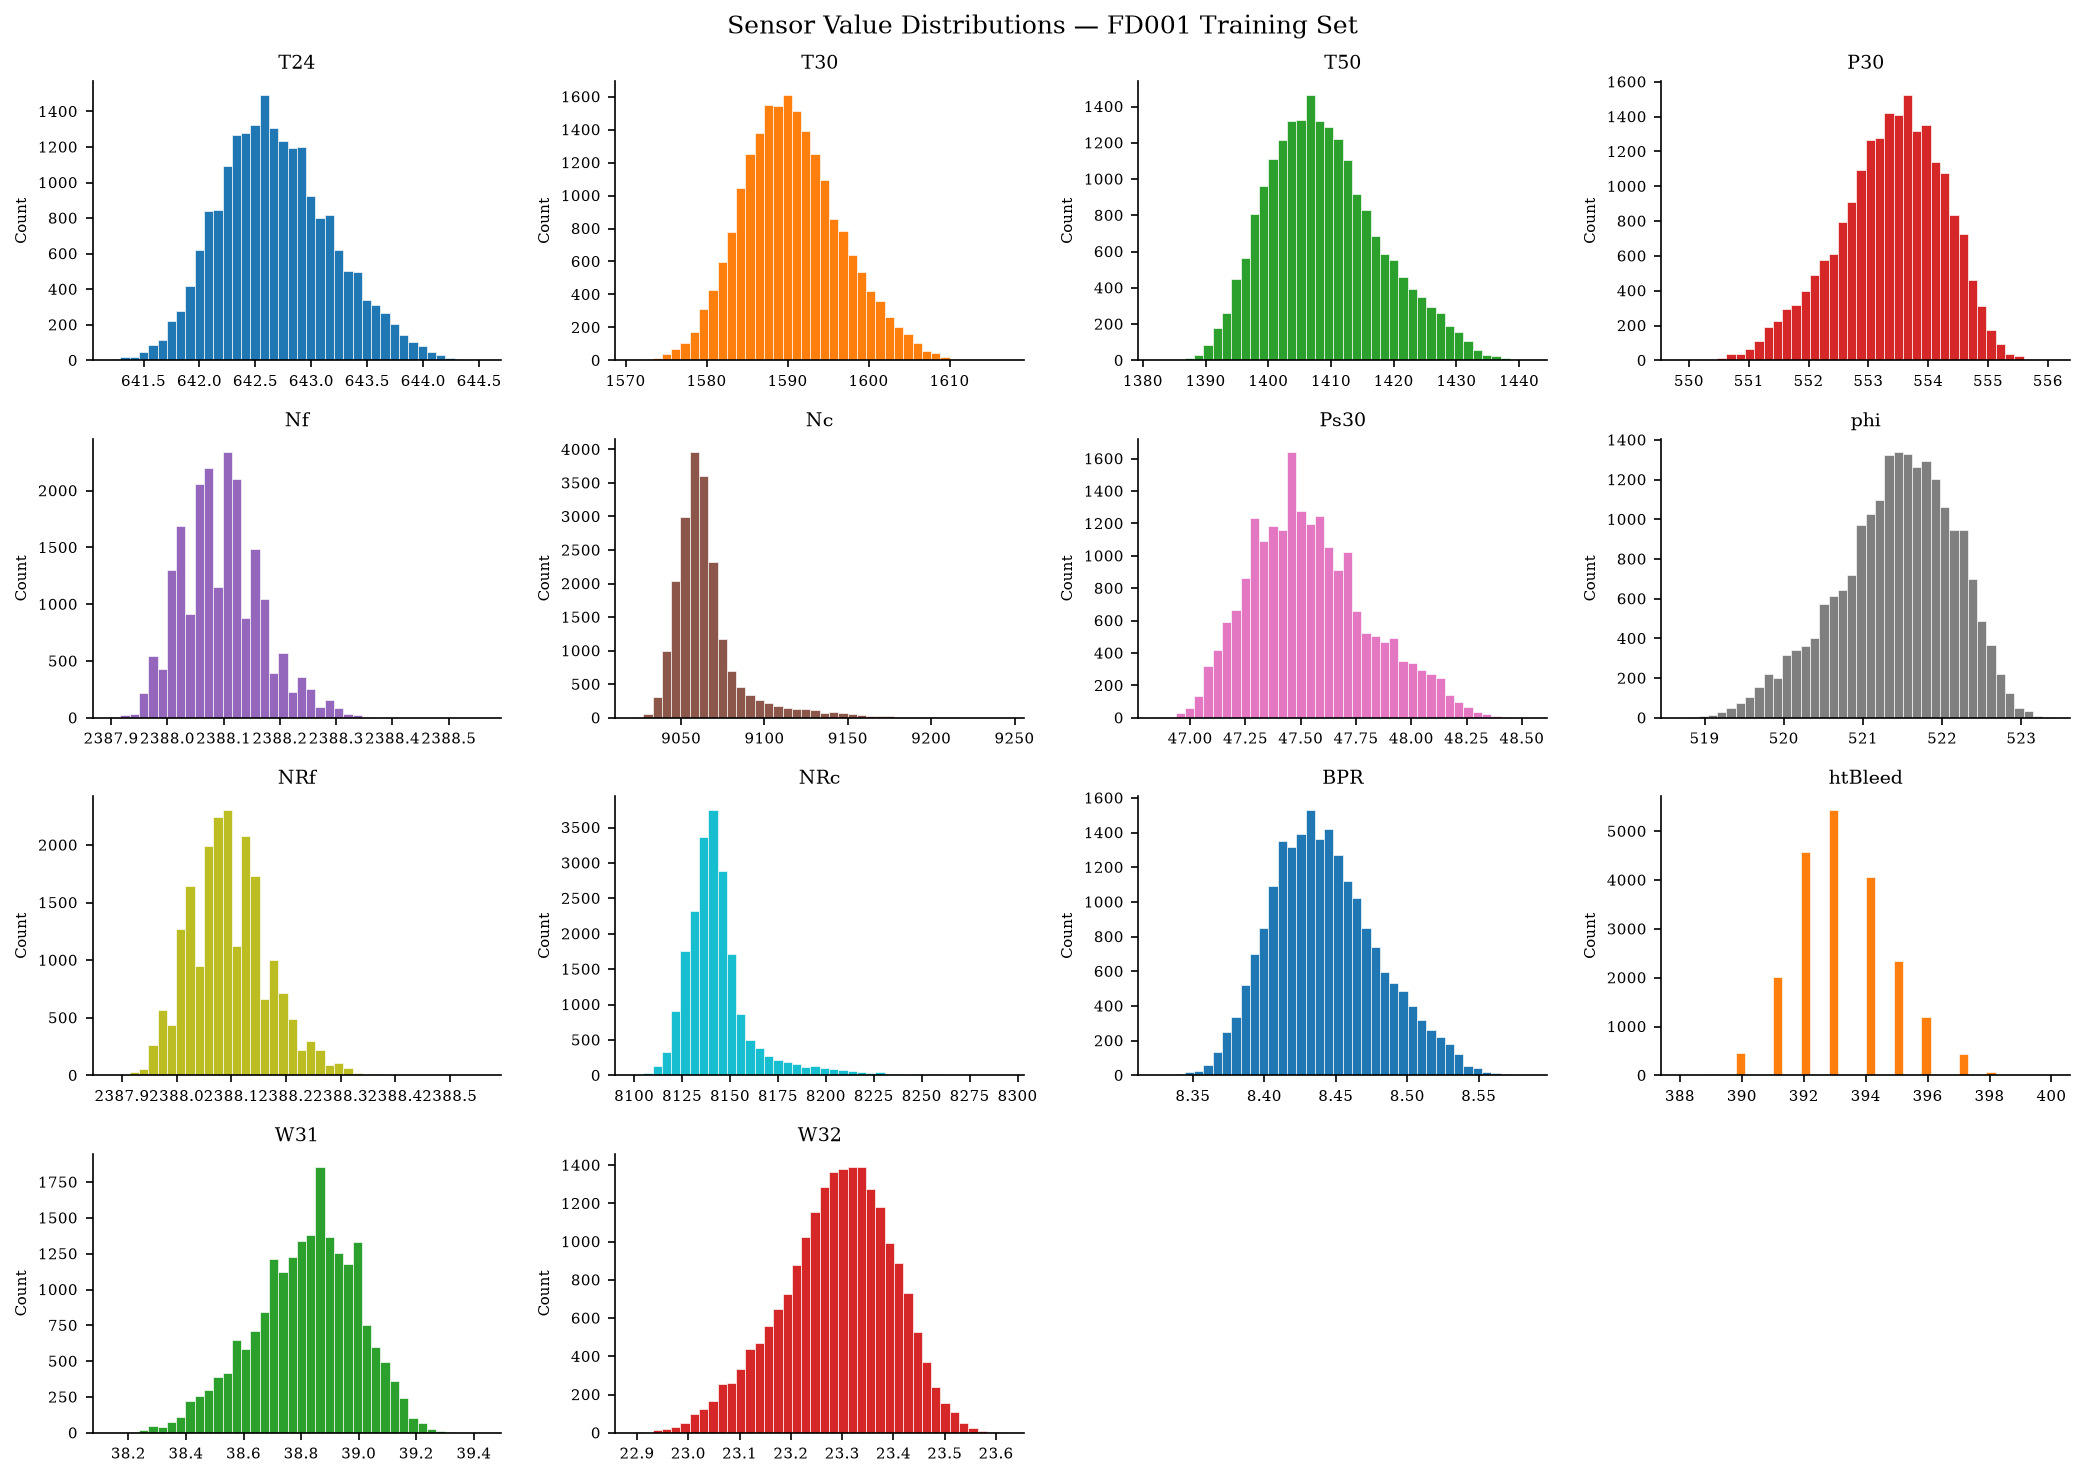

Saved → output/figures/IDA/FD001/sensor_distributions_FD001.png


In [17]:
# Side-by-side distributions of informative sensors
fig, axes = plt.subplots(4, 4, figsize=(14, 10))
fig.suptitle(f'Sensor Value Distributions — {DATASET} Training Set', fontsize=12)
axes = axes.flatten()

for i, s in enumerate(INFORMATIVE_SENSORS):
    ax = axes[i]
    ax.hist(train[s].dropna(), bins=40, color=PALETTE[i % 10], edgecolor='white', linewidth=0.3)
    ax.set_title(s, fontsize=9)
    ax.set_ylabel('Count', fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(len(INFORMATIVE_SENSORS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
fig.savefig(FIG_DIR / f'sensor_distributions_{DATASET}.png', bbox_inches='tight')
plt.show()
print(f'Saved → output/figures/IDA/{DATASET}/sensor_distributions_{DATASET}.png')

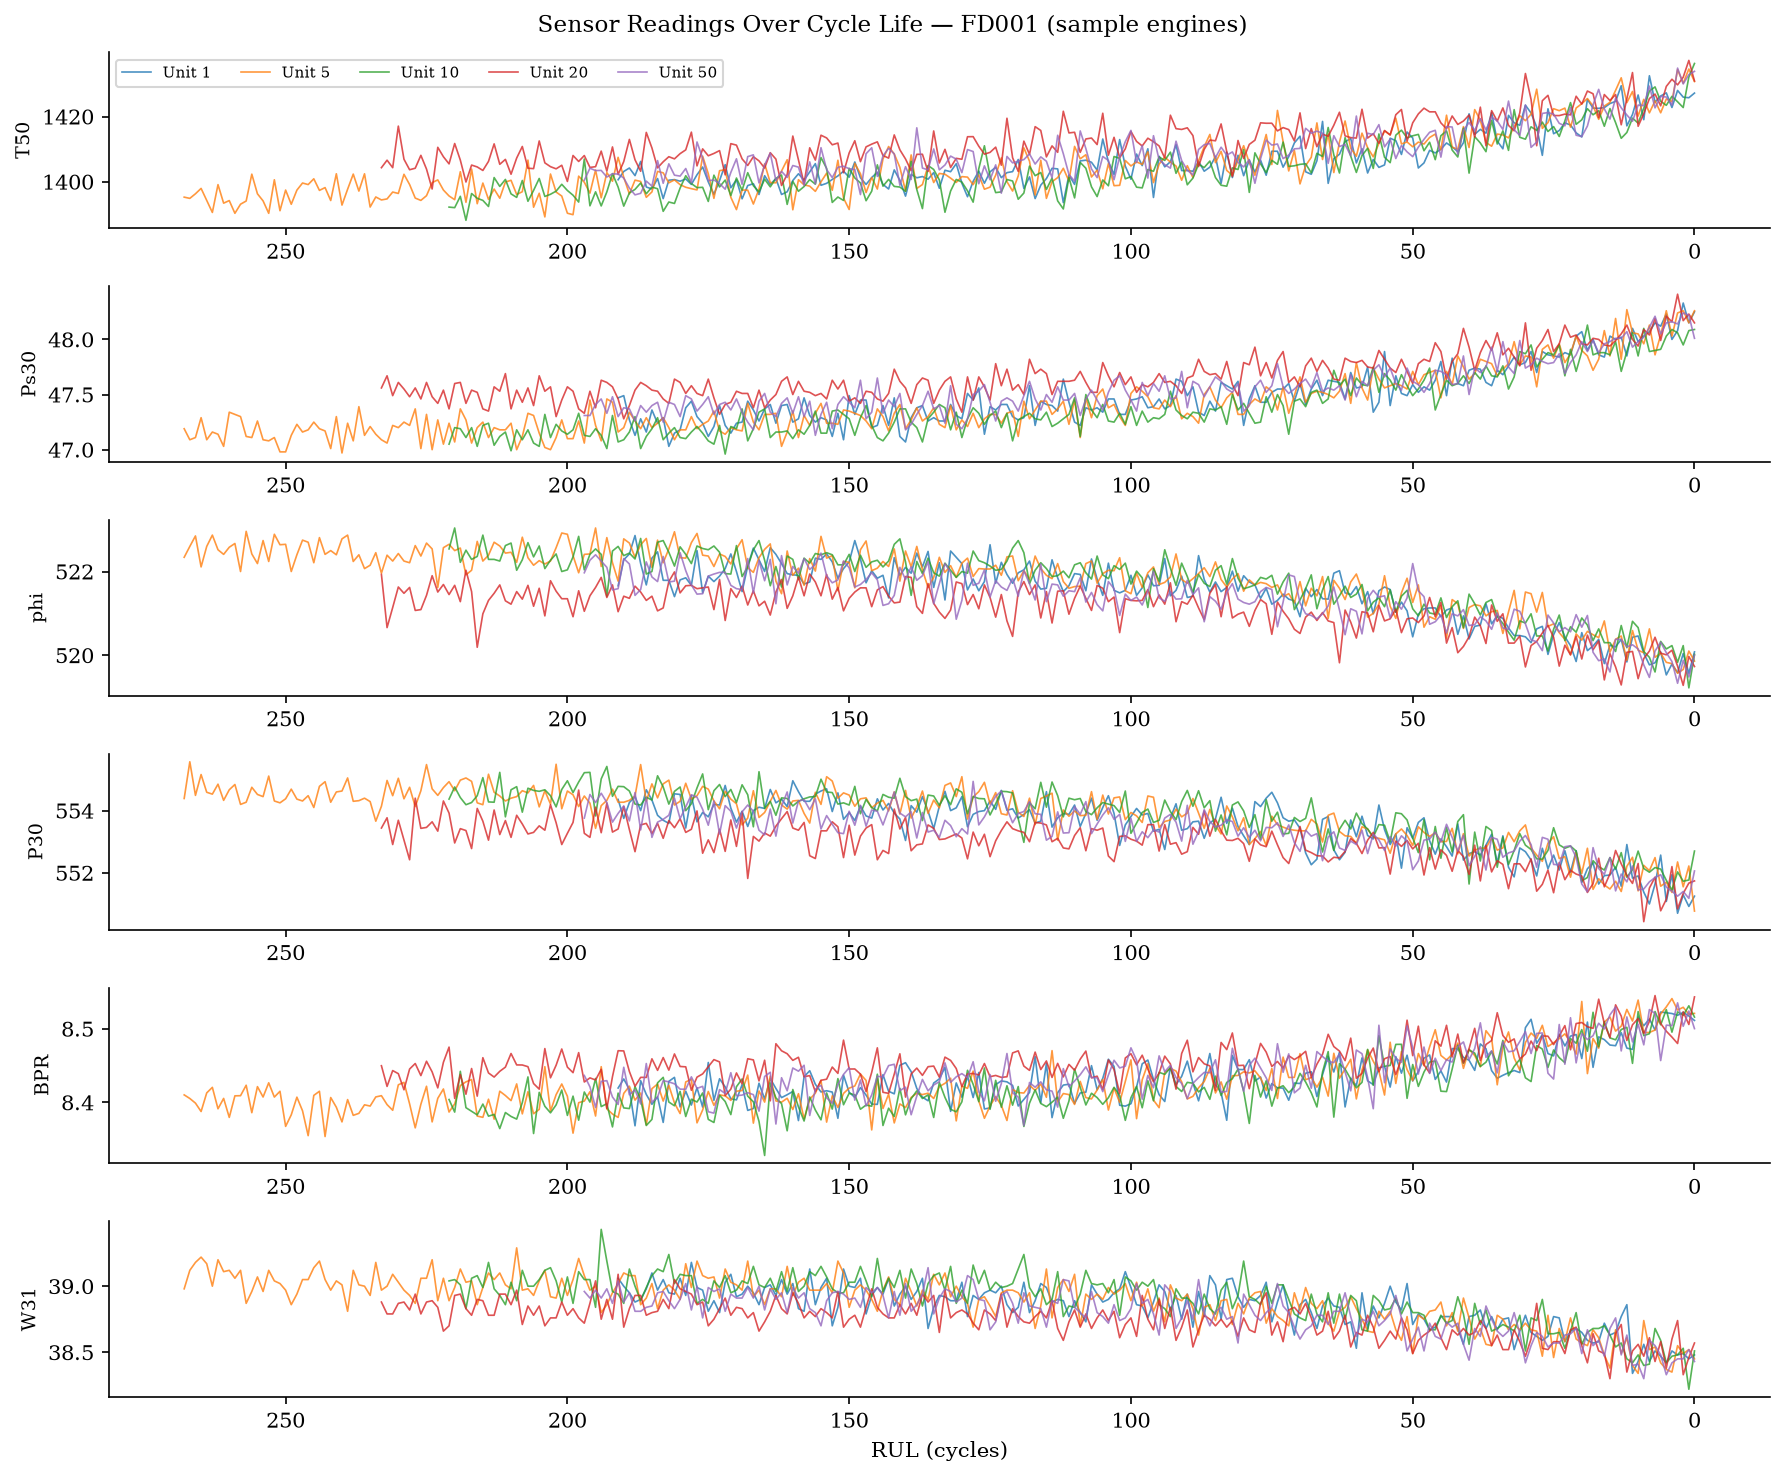

Saved → output/figures/IDA/FD001/sensor_timeseries_FD001.png


In [18]:
# Raw time-series for a sample of engines — visualise degradation in sensor readings
SAMPLE_UNITS = [int(u) for u in train['unit_id'].unique()[[0, 4, 9, 19, min(49, train['unit_id'].nunique()-1)]]]
PLOT_SENSORS = ['T50', 'Ps30', 'phi', 'P30', 'BPR', 'W31']

fig, axes = plt.subplots(len(PLOT_SENSORS), 1, figsize=(12, 10), sharex=False)
fig.suptitle(f'Sensor Readings Over Cycle Life — {DATASET} (sample engines)', fontsize=11)

for i, s in enumerate(PLOT_SENSORS):
    ax = axes[i]
    for j, uid in enumerate(SAMPLE_UNITS):
        unit_df = train[train['unit_id'] == uid]
        ax.plot(unit_df['RUL'], unit_df[s],
                linewidth=0.8, alpha=0.8, color=PALETTE[j], label=f'Unit {uid}')
    ax.invert_xaxis()
    ax.set_ylabel(s, fontsize=9)
    ax.set_xlabel('RUL (cycles)' if i == len(PLOT_SENSORS) - 1 else '')
    if i == 0:
        ax.legend(fontsize=7, ncol=len(SAMPLE_UNITS))

plt.tight_layout()
fig.savefig(FIG_DIR / f'sensor_timeseries_{DATASET}.png', bbox_inches='tight')
plt.show()
print(f'Saved → output/figures/IDA/{DATASET}/sensor_timeseries_{DATASET}.png')

---
## 10. RUL Label Structure

For **training** data, RUL is derived internally (`max_cycle - current_cycle`).
For **test** data, true RUL labels are provided in a separate file (`RUL_{dataset}.txt`), representing the remaining life at the last observed cycle.

In [19]:
train_rul = train.groupby('unit_id')['RUL'].max()

rul_row = {
    'Dataset': DATASET,
    'Test RUL — min': int(rul.min()),
    'Test RUL — median': int(rul.median()),
    'Test RUL — mean': f'{rul.mean():.1f}',
    'Test RUL — max': int(rul.max()),
    'Train max RUL (median)': int(train_rul.median()),
}

rul_df = pd.DataFrame([rul_row]).set_index('Dataset')
display(rul_df)
rul_df.to_csv(TABLE_DIR / 'rul_label_stats.csv')
print('Saved → output/tables/IDA/{}/rul_label_stats.csv'.format(DATASET))

,Test RUL — min,Test RUL — median,Test RUL — mean,Test RUL — max,Train max RUL (median)
Dataset,,,,,
FD001,7,86,75.5,145,198


Saved → output/tables/IDA/FD001/rul_label_stats.csv


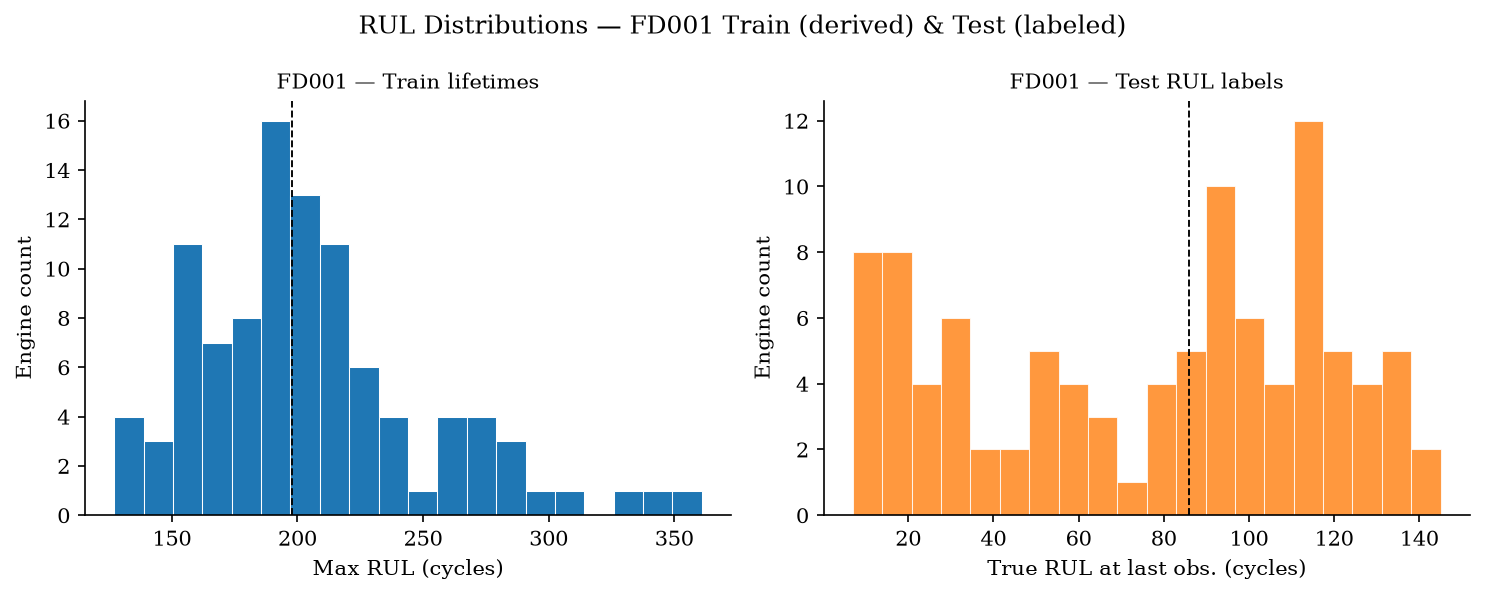

Saved → output/figures/IDA/FD001/rul_distributions.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(f'RUL Distributions — {DATASET} Train (derived) & Test (labeled)', fontsize=12)

ax = axes[0]
ax.hist(train_rul, bins=20, color=PALETTE[0], edgecolor='white', linewidth=0.5)
ax.set_title(f'{DATASET} — Train lifetimes', fontsize=10)
ax.set_xlabel('Max RUL (cycles)')
ax.set_ylabel('Engine count')
ax.axvline(train_rul.median(), color='k', linestyle='--', linewidth=0.9)

ax = axes[1]
ax.hist(rul, bins=20, color=PALETTE[1], edgecolor='white', linewidth=0.5, alpha=0.8)
ax.set_title(f'{DATASET} — Test RUL labels', fontsize=10)
ax.set_xlabel('True RUL at last obs. (cycles)')
ax.set_ylabel('Engine count')
ax.axvline(rul.median(), color='k', linestyle='--', linewidth=0.9)

plt.tight_layout()
fig.savefig(FIG_DIR / 'rul_distributions.png', bbox_inches='tight')
plt.show()
print(f'Saved → output/figures/IDA/{DATASET}/rul_distributions.png')

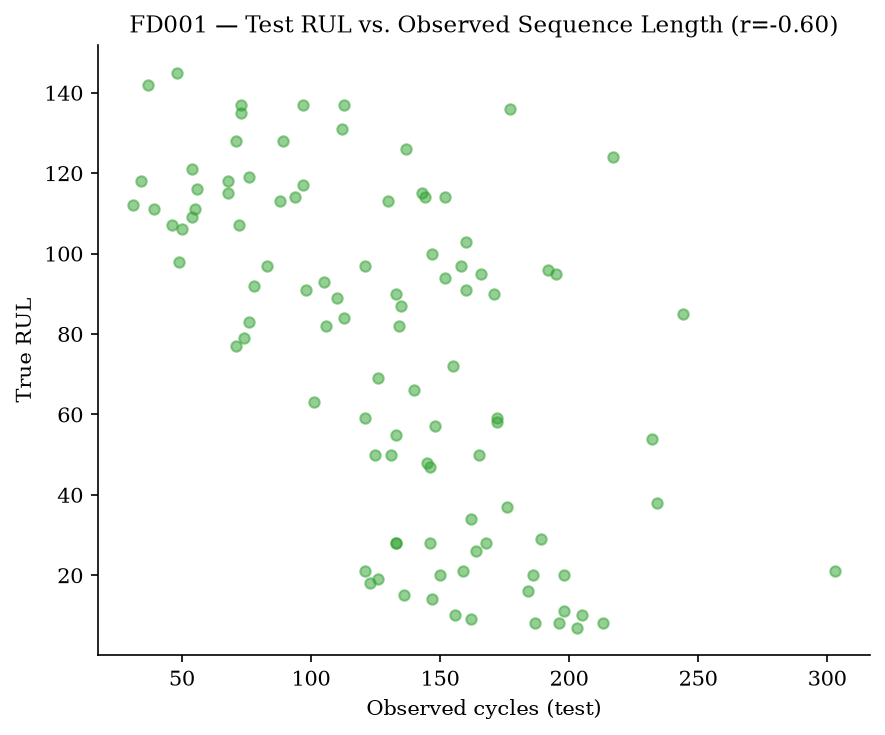

Saved → output/figures/IDA/FD001/test_rul_vs_obs_length.png
Correlation (obs. length vs true RUL): r = -0.598


In [21]:
# Correlation between test RUL label and observed sequence length
obs_len = test.groupby('unit_id')['cycle'].max().values
rul_vals = rul.values
corr = np.corrcoef(obs_len, rul_vals)[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(obs_len, rul_vals, alpha=0.5, s=25, color=PALETTE[2])
ax.set_title(f'{DATASET} — Test RUL vs. Observed Sequence Length (r={corr:.2f})', fontsize=11)
ax.set_xlabel('Observed cycles (test)')
ax.set_ylabel('True RUL')
plt.tight_layout()
fig.savefig(FIG_DIR / 'test_rul_vs_obs_length.png', bbox_inches='tight')
plt.show()
print(f'Saved → output/figures/IDA/{DATASET}/test_rul_vs_obs_length.png')
print(f'Correlation (obs. length vs true RUL): r = {corr:.3f}')

---
## 11. Summary & Key Findings

In [22]:
print('=' * 65)
print(f'  IDA SUMMARY — {DATASET}')
print('=' * 65)

print(f"""
SCHEMA
  26 columns: unit_id | cycle | 3 settings | 21 sensors
  All columns numeric; missing cells = {int(train.isnull().sum().sum() + test.isnull().sum().sum())}.
  Duplicate rows = {int(train.duplicated().sum() + test.duplicated().sum())}.

DATASET
  {DATASET}: {dim_row['Train engines']} train engines, {dim_row['Test engines']} test engines
  1 operating condition, fault mode: HPC degradation

CYCLE STRUCTURE
  Train sequences = full engine lifetimes (failure observed): {cs_df.iloc[0]['Min cycles']}-{cs_df.iloc[0]['Max cycles']} cycles (median {cs_df.iloc[0]['Median cycles']}).
  Test sequences = truncated (engine still running at last obs.): {cs_df.iloc[1]['Min cycles']}-{cs_df.iloc[1]['Max cycles']} cycles.
  setting_3 is constant → drop. setting_1/2 round to a single value → 1 operating condition confirmed.

SENSORS — CONSTANT (drop; consistent with project-wide 4-dataset convention)
  {CONSTANT_SENSORS}  ({len(CONSTANT_SENSORS)} sensors)
  ({DATASET}-specific zero-variance sensors alone: {const_this_ds})

SENSORS — INFORMATIVE ({len(INFORMATIVE_SENSORS)} remaining)
  {INFORMATIVE_SENSORS}
  → Further selection via EDA_{DATASET}.ipynb (Mann-Kendall, monotonicity, trendability, MI, VIF)

RUL LABELS
  Training RUL: derived from max_cycle - current_cycle.
  Test RUL: provided externally; median {int(rul.median())} cycles.
  Correlation between observed test sequence length and true RUL: r = {corr:.3f}
  (shorter sequences = less degradation seen = more RUL remaining).

NEXT STEP → EDA_{DATASET}.ipynb
  Apply Mann-Kendall, monotonicity/trendability scores, MI, VIF
  to the {len(INFORMATIVE_SENSORS)} informative sensors to select the final sensor subset for {DATASET}.
""")

  IDA SUMMARY — FD001

SCHEMA
  26 columns: unit_id | cycle | 3 settings | 21 sensors
  All columns numeric; missing cells = 0.
  Duplicate rows = 0.

DATASET
  FD001: 100 train engines, 100 test engines
  1 operating condition, fault mode: HPC degradation

CYCLE STRUCTURE
  Train sequences = full engine lifetimes (failure observed): 128-362 cycles (median 199).
  Test sequences = truncated (engine still running at last obs.): 31-303 cycles.
  setting_3 is constant → drop. setting_1/2 round to a single value → 1 operating condition confirmed.

SENSORS — CONSTANT (drop; consistent with project-wide 4-dataset convention)
  ['T2', 'P2', 'P15', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']  (7 sensors)
  (FD001-specific zero-variance sensors alone: ['T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd'])

SENSORS — INFORMATIVE (14 remaining)
  ['T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']
  → Further selection via EDA_FD001.ipynb (Mann-Kendall, mo

---
*End of IDA notebook. All tables and figures saved to `output/tables/IDA/FD001/` and `output/figures/IDA/FD001/`.*